In [1]:
# Primetrade.ai – Data Science Intern Assignment
# Author: Jaiganesh Mabbu

# Trader Performance vs Market Sentiment

Objective:
Analyze how Bitcoin market sentiment (Fear / Greed) influences trader behavior and profitability on Hyperliquid.

Datasets:
1. Bitcoin Fear & Greed Index
2. Historical Trader Data

Key Goals:
- Align trading data with daily market sentiment
- Analyze how trader performance changes with sentiment
- Identify behavioral patterns and trader segments
- Propose actionable trading insights

## Part A:- Data Preparation

In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [3]:
#Load Data
sentiment_df = pd.read_csv("fear_greed_index.csv")
trader_df = pd.read_csv("historical_data.csv")

In [4]:
#Basic Dataset Overview
print("Sentiment dataset shape:", sentiment_df.shape)
print("Trader dataset shape:", trader_df.shape)

Sentiment dataset shape: (2644, 4)
Trader dataset shape: (211224, 16)


In [5]:
#Preview Data
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
#Preview Data
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
#Dataset Info
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [8]:
#Dataset Info
trader_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [9]:
#Convert Time Columns (Important) Sentiment dataset
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], errors='coerce')

In [10]:
#Trader dataset Your format: DD-MM-YYYY HH:MM So:
trader_df['Timestamp IST'] = pd.to_datetime(trader_df['Timestamp IST'], dayfirst=True, errors='coerce')

In [11]:
#Create Daily Date Column
trader_df['date'] = trader_df['Timestamp IST'].dt.date
sentiment_df['date'] = sentiment_df['date'].dt.date

In [12]:
#Merge Both Datasets
merged_df = pd.merge(trader_df, sentiment_df[['date','classification']], on='date', how='left')

In [13]:
merged_df[['date','classification']].head()

,date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed


In [14]:
#Convert Numeric Columns

merged_df['Closed PnL'] = pd.to_numeric(merged_df['Closed PnL'], errors='coerce')
merged_df['Size USD'] = pd.to_numeric(merged_df['Size USD'], errors='coerce')
merged_df['Execution Price'] = pd.to_numeric(merged_df['Execution Price'], errors='coerce')

In [15]:
merged_df.shape
merged_df.columns
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [16]:
#Create Profit Indicator (Win / Loss):- This helps compute win rate.
merged_df['is_win'] = merged_df['Closed PnL'] > 0

merged_df[['Closed PnL','is_win']].head()

,Closed PnL,is_win
0,0.0,False
1,0.0,False
2,0.0,False
3,0.0,False
4,0.0,False


In [17]:
#Daily PnL:- Total profit/loss generated each day.
daily_pnl = merged_df.groupby('date')['Closed PnL'].sum().reset_index()

daily_pnl.rename(columns={'Closed PnL':'daily_pnl'}, inplace=True)

daily_pnl.head()

,date,daily_pnl
0,2023-05-01,0.000000
1,2023-12-05,0.000000
2,2023-12-14,-205.434737
3,2023-12-15,-24.632034
4,2023-12-16,0.000000


In [18]:
#Number of Trades Per Day
daily_trades = merged_df.groupby('date').size().reset_index(name='num_trades')

In [19]:
#Average Trade Size:- Using USD value.
avg_trade_size = merged_df.groupby('date')['Size USD'].mean().reset_index()

avg_trade_size.rename(columns={'Size USD':'avg_trade_size'}, inplace=True)

In [20]:
#Win Rate Per Day
win_rate = merged_df.groupby('date')['is_win'].mean().reset_index()

win_rate.rename(columns={'is_win':'win_rate'}, inplace=True)

In [21]:
#Long vs Short Ratio
side_counts = merged_df.groupby(['date','Side']).size().unstack(fill_value=0)

side_counts['long_short_ratio'] = side_counts['BUY'] / (side_counts['SELL'] + 1)

side_counts = side_counts.reset_index()

In [22]:
#Combine All Metrics:- Now merge all metrics into one analytical dataset.

metrics_df = daily_pnl.merge(daily_trades, on='date') \
                      .merge(avg_trade_size, on='date') \
                      .merge(win_rate, on='date') \
                      .merge(side_counts[['date','long_short_ratio']], on='date')

In [23]:
#Add Sentiment:- Each day has a sentiment classification.
metrics_df = metrics_df.merge(sentiment_df[['date','classification']], on='date', how='left')

In [24]:
metrics_df.head()
metrics_df.describe()

,daily_pnl,num_trades,avg_trade_size,win_rate,long_short_ratio
count,480.000000,480.000000,480.000000,480.000000,480.000000
mean,21451.997799,440.050000,6141.750924,0.366458,2.506255
std,71861.463509,809.748711,5575.022860,0.263652,6.354074
min,-419020.225731,1.000000,0.110000,0.000000,0.000000
25%,7.253957,18.000000,2201.186680,0.182367,0.464448
50%,1118.961740,67.500000,4337.977065,0.352779,0.885621
75%,10669.321765,520.500000,8195.748723,0.503187,1.738705
max,616413.032233,6246.000000,34988.580000,1.000000,74.000000


## Part B:- Analysis

In [25]:
#Check Sentiment Distribution
metrics_df['classification'].value_counts()

classification
Greed            193
Extreme Greed    114
Fear              91
Neutral           67
Extreme Fear      14
Name: count, dtype: int64

In [26]:
#Performance by Sentiment
pnl_by_sentiment = metrics_df.groupby('classification')['daily_pnl'].mean().reset_index()

pnl_by_sentiment

,classification,daily_pnl
0,Extreme Fear,52793.589178
1,Extreme Greed,23817.292199
2,Fear,36891.818040
3,Greed,11140.566181
4,Neutral,19297.323516


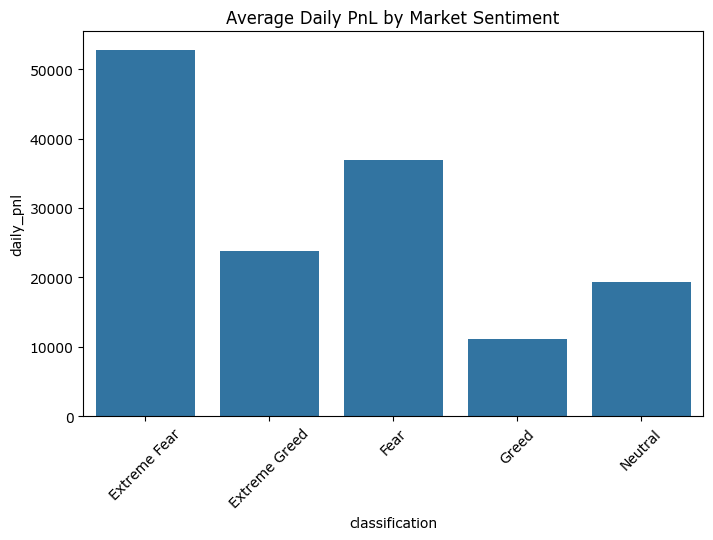

In [27]:
#Visualization (Important Chart)
plt.figure(figsize=(8,5))
sns.barplot(data=pnl_by_sentiment, x='classification', y='daily_pnl')
plt.title("Average Daily PnL by Market Sentiment")
plt.xticks(rotation=45)
plt.show()

### Insight 1
    Trader profitability tends to increase during fear-driven market conditions. The highest average daily PnL occurs during Extreme Fear periods, suggesting that volatile market environments create more profitable opportunities for active traders. In contrast, Greed periods show lower average profitability, potentially due to more stable market conditions and reduced volatility.

    Although Extreme Fear shows the highest profitability, the sample size is relatively small, which may amplify the average value.

  classification   num_trades
0   Extreme Fear  1528.571429
1  Extreme Greed   350.807018
2           Fear   679.527473
3          Greed   260.637306
4        Neutral   562.477612


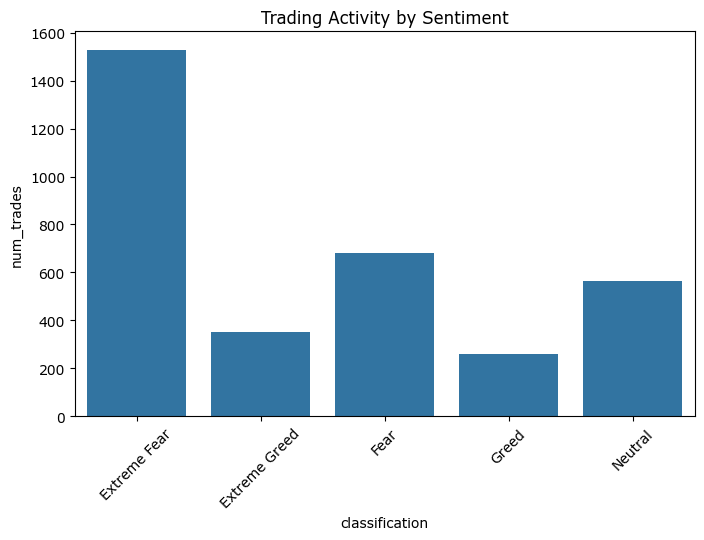

In [28]:
#Trader Behavior by Sentiment:- Trades per day:
trades_by_sentiment = metrics_df.groupby('classification')['num_trades'].mean().reset_index()

print(trades_by_sentiment)

plt.figure(figsize=(8,5))
sns.barplot(data=trades_by_sentiment, x='classification', y='num_trades')
plt.title("Trading Activity by Sentiment")
plt.xticks(rotation=45)
plt.show()

  classification     daily_pnl
0   Extreme Fear  52793.589178
1  Extreme Greed  23817.292199
2           Fear  36891.818040
3          Greed  11140.566181
4        Neutral  19297.323516


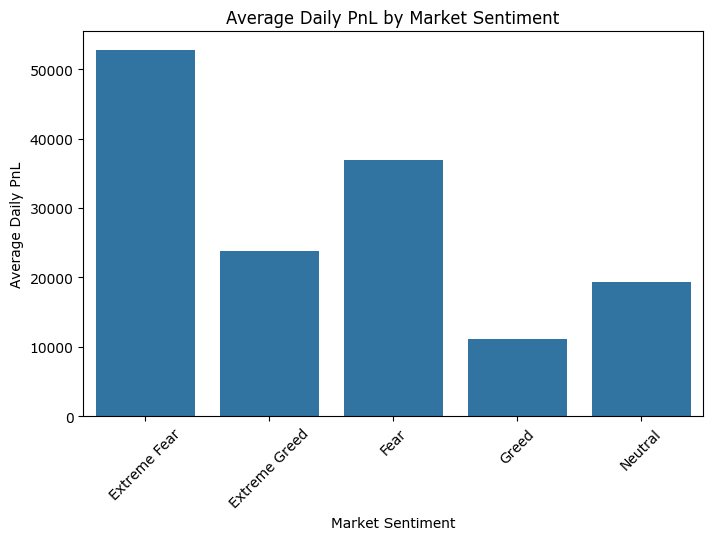

In [29]:
#Average Profitability by Sentiment
pnl_by_sentiment = metrics_df.groupby('classification')['daily_pnl'].mean().reset_index()

print(pnl_by_sentiment)

plt.figure(figsize=(8,5))
sns.barplot( data=pnl_by_sentiment, x='classification', y='daily_pnl')
plt.title("Average Daily PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Daily PnL")
plt.xticks(rotation=45)
plt.show()

  classification   num_trades
0   Extreme Fear  1528.571429
1  Extreme Greed   350.807018
2           Fear   679.527473
3          Greed   260.637306
4        Neutral   562.477612


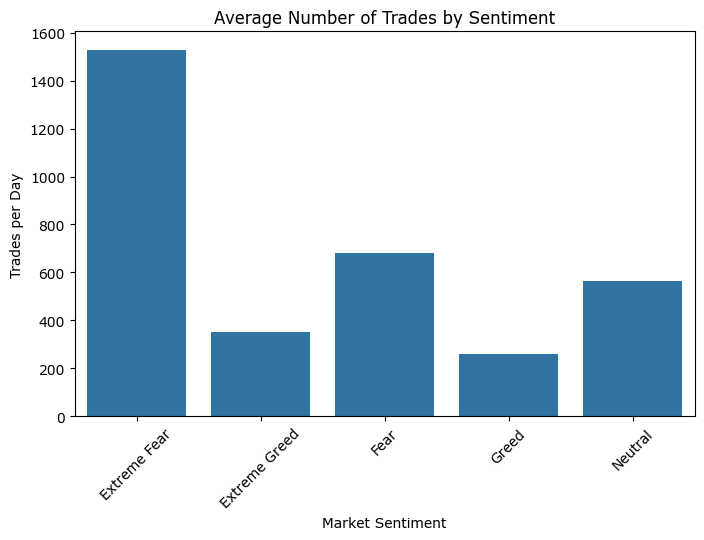

In [30]:
#Trading Activity by Sentiment
trades_by_sentiment = metrics_df.groupby('classification')['num_trades'].mean().reset_index()

print(trades_by_sentiment)

plt.figure(figsize=(8,5))
sns.barplot( data=trades_by_sentiment, x='classification', y='num_trades')
plt.title("Average Number of Trades by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trades per Day")
plt.xticks(rotation=45)
plt.show()

### Insight 2 — Trading Activity

    Traders are significantly more active during Extreme Fear periods, with an average of over 1500 trades per day, compared to roughly 260 trades during Greed periods.
    This suggests that volatile or uncertain market conditions lead to increased trading activity as traders attempt to capitalize on rapid price movements.

  classification  avg_trade_size
0   Extreme Fear     4091.804366
1  Extreme Greed     4410.524482
2           Fear     6524.294937
3          Greed     6735.295813
4        Neutral     7157.527121


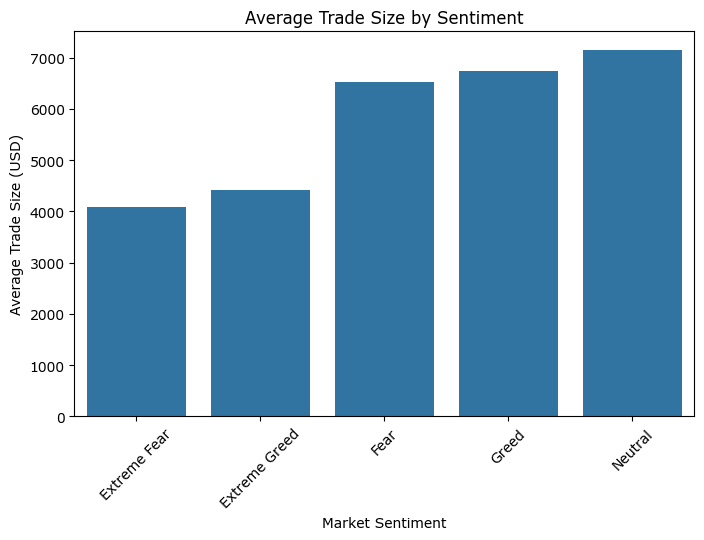

In [31]:
#Risk Behaviour (Position Size)
size_by_sentiment = metrics_df.groupby('classification')['avg_trade_size'].mean().reset_index()

print(size_by_sentiment)

plt.figure(figsize=(8,5))
sns.barplot(data=size_by_sentiment, x='classification', y='avg_trade_size')
plt.title("Average Trade Size by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xticks(rotation=45)
plt.show()

### Insight 3 — Risk Behaviour
    Average trade size is larger during Greed and Neutral conditions, suggesting traders are more confident and willing to commit larger capital when the market sentiment is positive.

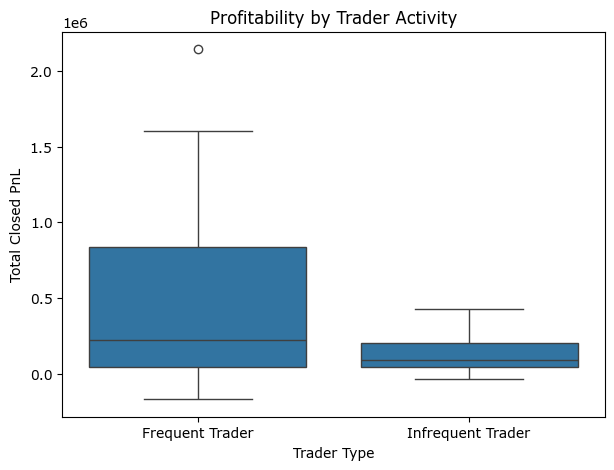

In [32]:
# Segment Traders by Trading Activity
trader_activity = merged_df.groupby('Account').size().reset_index(name='num_trades')

median_trades = trader_activity['num_trades'].median()

trader_activity['trader_type'] = trader_activity['num_trades'].apply(
    lambda x: 'Frequent Trader' if x > median_trades else 'Infrequent Trader'
)

trader_activity.head()
# Profitability Comparison Graph 
# Calculate total PnL per trader
activity_pnl = merged_df.groupby('Account')['Closed PnL'].sum().reset_index()

# Merge trader type
activity_pnl = activity_pnl.merge(trader_activity[['Account','trader_type']], on='Account')

# Plot
plt.figure(figsize=(7,5))
sns.boxplot( data=activity_pnl, x='trader_type', y='Closed PnL')
plt.title("Profitability by Trader Activity")
plt.xlabel("Trader Type")
plt.ylabel("Total Closed PnL")
plt.show()

### Insight

    Frequent traders tend to achieve higher maximum profits compared to infrequent traders. However, their profitability also shows higher variability, indicating that increased trading activity may lead to greater profit opportunities but also exposes traders to higher performance volatility. In contrast, infrequent traders exhibit more stable but generally lower profit outcomes.

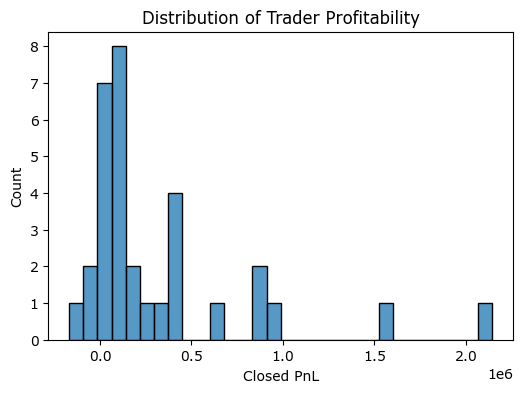

In [33]:
#Next Segment (Profitability):- Now we segment by PnL.
trader_profit = merged_df.groupby('Account')['Closed PnL'].sum().reset_index()

median_profit = trader_profit['Closed PnL'].median()

trader_profit['profit_segment'] = trader_profit['Closed PnL'].apply(
    lambda x: 'High Profit Trader' if x > median_profit else 'Low Profit Trader'
)

trader_profit.head()
#Graph
plt.figure(figsize=(6,4))
sns.histplot(trader_profit['Closed PnL'], bins=30)
plt.title("Distribution of Trader Profitability")
plt.show()

### Insight

    Traders were categorized as High Profit or Low Profit based on the median total Closed PnL per account. This approach ensures a balanced comparison between profitable and less profitable traders, enabling further analysis of behavioral differences between these groups.

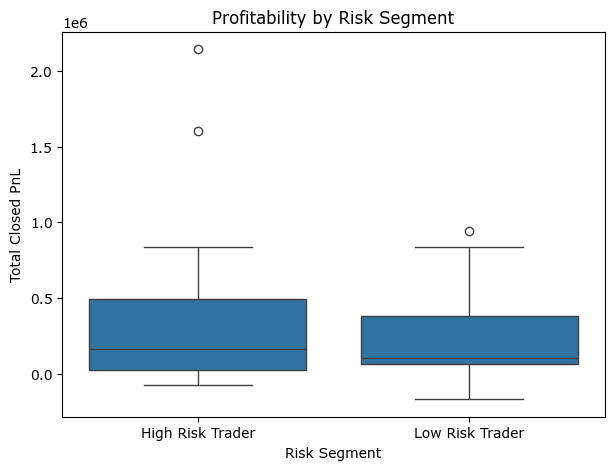

In [34]:
# Risk Behavior Segment
trader_risk = merged_df.groupby('Account')['Size USD'].mean().reset_index()

median_risk = trader_risk['Size USD'].median()

trader_risk['risk_segment'] = trader_risk['Size USD'].apply(
    lambda x: 'High Risk Trader' if x > median_risk else 'Low Risk Trader'
)

trader_risk.head()
#Profitability Comparison Graph
# Calculate total PnL per trader
risk_pnl = merged_df.groupby('Account')['Closed PnL'].sum().reset_index()

# Merge risk segment
risk_pnl = risk_pnl.merge(
    trader_risk[['Account','risk_segment']],
    on='Account'
)

# Plot
plt.figure(figsize=(7,5))
sns.boxplot(data=risk_pnl, x='risk_segment', y='Closed PnL')
plt.title("Profitability by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Total Closed PnL")
plt.show()

### Insight

    High-risk traders demonstrate greater variability in profitability, with some achieving very large profits but also experiencing wider performance fluctuations. Low-risk traders show more consistent performance with fewer extreme outcomes. This suggests that larger trade sizes increase both potential returns and profit volatility.

## Part C: Strategy Recommendations Based on Market Sentiment

Based on the analysis of trading activity, profitability, and trader behavior across different market sentiment conditions, several strategic insights can be derived. The following recommendations highlight how trading strategies can be adapted to maximize profitability while managing risk.

### 1. Increase Trading Activity During Fear-Driven Markets

The analysis showed that average daily profitability is highest during Fear and Extreme Fear market conditions. These periods are typically associated with higher market volatility, which creates more opportunities for traders to capture price movements.

**Recommendation:**  
Traders may benefit from increasing trading activity during fear-driven market conditions, as volatile environments often provide more short-term trading opportunities compared to stable markets.

### 2. Adopt a Conservative Approach During Greed Periods

The results indicate that average profitability tends to be lower during Greed and Extreme Greed conditions. These market phases often reflect strong optimism where price movements may become more stable or overextended.

**Recommendation:**  
During highly optimistic market conditions, traders should consider adopting a more conservative strategy by reducing trade frequency or position sizes to manage potential downside risks.


### 3. Implement Adaptive Risk Management

The trader segmentation analysis revealed that high-risk traders achieve larger profits but also experience greater variability in performance. This indicates that larger trade sizes can amplify both gains and losses.

**Recommendation:**  
Traders should apply adaptive risk management strategies, adjusting position sizes based on market conditions. Larger positions may be appropriate during high-volatility environments, while smaller positions should be used during stable or uncertain markets.


### 4. Leverage Volatility-Based Trading Strategies

Fear-driven market periods tend to produce larger price fluctuations and increased trading activity. Such environments are often well-suited for strategies that rely on short-term price movements.

**Recommendation:**  
Traders may benefit from implementing volatility-based trading strategies, such as momentum trading or short-term mean-reversion approaches, particularly during periods of high market uncertainty.

### 5. Balance Trading Frequency with Risk Exposure

The segmentation analysis showed that frequent traders can achieve higher maximum profits but also experience greater variability in outcomes. This suggests that while increased trading activity can improve profit potential, it can also increase risk exposure.

**Recommendation:**  
Traders should maintain a balance between trading frequency and risk management. Consistent trade selection and disciplined execution can help capture opportunities while avoiding excessive exposure to market volatility.

### Conclusion

Overall, the analysis suggests that market sentiment plays an important role in shaping trading behavior and profitability. Fear-driven markets tend to provide greater trading opportunities due to higher volatility, while greed-driven markets may require more cautious strategies. By adapting trading activity, position sizing, and risk management practices according to prevailing sentiment conditions, traders can potentially improve performance while controlling risk.

## Bonus Section — Trader Behavioral Archetypes Using Clustering

To further understand trader behavior, an unsupervised machine learning approach was used to group traders into behavioral archetypes. By clustering traders based on their trading activity, profitability, and risk exposure, we can identify distinct trading styles present in the dataset.

The clustering analysis uses the following behavioral features:

- Number of trades executed
- Average trade size
- Total profitability (Closed PnL)

These features capture key aspects of trader behavior including activity level, risk-taking, and financial performance.

In [35]:
#Create Trader Feature Dataset
trader_features = merged_df.groupby('Account').agg(
    num_trades=('Trade ID','count'),
    avg_trade_size=('Size USD','mean'),
    total_pnl=('Closed PnL','sum')
).reset_index()

trader_features.head()

,Account,num_trades,avg_trade_size,total_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,16159.576734,1.600230e+06
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,1653.226327,4.788532e+04
2,0x271b280974205ca63b716753467d5a371de622ab,3809,8893.000898,-7.043619e+04
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,507.626933,1.324648e+05
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,3138.894782,1.686580e+05


In [36]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

features = trader_features[['num_trades','avg_trade_size','total_pnl']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [37]:
#KMeans Clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(scaled_features)
trader_features.head()

,Account,num_trades,avg_trade_size,total_pnl,cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,16159.576734,1.600230e+06,0
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,1653.226327,4.788532e+04,1
2,0x271b280974205ca63b716753467d5a371de622ab,3809,8893.000898,-7.043619e+04,1
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,507.626933,1.324648e+05,1
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,3138.894782,1.686580e+05,1


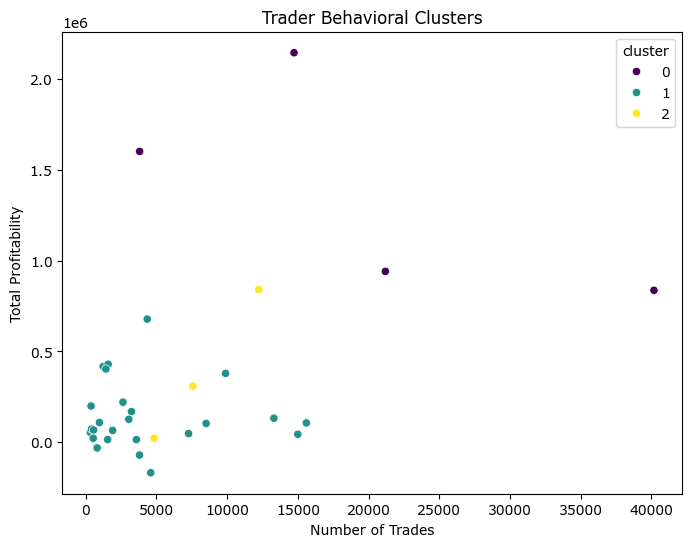

In [38]:
#Visualize Clusters
plt.figure(figsize=(8,6))
sns.scatterplot(data=trader_features, x='num_trades', y='total_pnl', hue='cluster', palette='viridis')
plt.title("Trader Behavioral Clusters")
plt.xlabel("Number of Trades")
plt.ylabel("Total Profitability")
plt.show()

### Cluster Interpretation

The clustering analysis groups traders into three behavioral archetypes based on their trading activity, average trade size, and total profitability.

#### Cluster 0 — High-Performing Active Traders
This cluster contains traders with very high profitability and relatively high trading activity. These traders execute a large number of trades and achieve the highest profit outcomes in the dataset. They likely represent highly active traders who effectively exploit market opportunities and volatility.

#### Cluster 1 — Low Activity / Low Profit Traders
Traders in this cluster show low trading activity and relatively low profitability. Most points in this cluster are concentrated in the lower-left region of the plot, indicating fewer trades and smaller profit outcomes. These traders may follow more conservative or less frequent trading strategies.

#### Cluster 2 — Moderate Activity Opportunistic Traders
This cluster represents traders with moderate trading activity and moderate profitability. They trade more selectively compared to highly active traders but are still able to capture meaningful profits. These traders may focus on opportunistic trades rather than constant market participation.

#### Key Insight
The clustering results suggest that trading activity and profitability are positively related for some traders, but not uniformly across all participants. While highly active traders can achieve very high profits, many traders with lower activity levels exhibit more modest and stable performance.